In [ ]:
#LSTM Model
#Long Short Term Memory

import pandas_datareader as web
import pandas as pd
import numpy as np
import math
import datetime as dt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import matplotlib.pyplot as plt

In [ ]:
company = "RELIANCE.NS"
start = dt.datetime(2010,1,1)
end = dt.datetime(2021,6,20)

data = web.DataReader(company, 'yahoo', start, end)

In [ ]:
data.tail()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2021-06-15,2274.899902,2240.300049,2261.000000,2250.000000,7002898.0,2250.000000
2021-06-16,2247.050049,2205.850098,2244.899902,2211.600098,4982975.0,2211.600098
2021-06-17,2235.000000,2179.899902,2200.000000,2215.649902,7266765.0,2215.649902
2021-06-18,2235.000000,2184.350098,2225.500000,2225.649902,13553801.0,2225.649902
2021-06-21,2247.500000,2200.149902,2203.500000,2237.250000,5622138.0,2237.250000


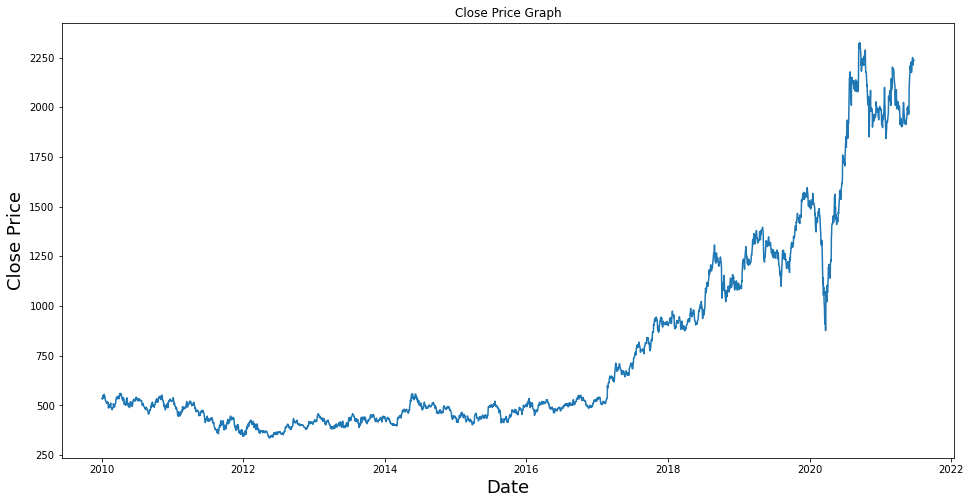

In [ ]:
#Plotting the graph of stock price

plt.figure(figsize=(16,8))
plt.title("Close Price Graph")
plt.plot(data['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.show()

In [ ]:
#Prepare Data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data['Close'].values.reshape(-1,1))
prediction_days = 60

In [ ]:
x_train = []
y_train = []

for x in range(prediction_days, len(scaled_data)):
  x_train.append(scaled_data[x-prediction_days:x, 0])
  y_train.append(scaled_data[x, 0])

In [ ]:
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [ ]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape = (x_train.shape[1],1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, batch_size=32, epochs=25)

Epoch 1/25
87/87 [==============================] - 10s 64ms/step - loss: 0.0079
Epoch 2/25
87/87 [==============================] - 5s 61ms/step - loss: 4.7770e-04
Epoch 3/25
87/87 [==============================] - 5s 62ms/step - loss: 4.4473e-04
Epoch 4/25
87/87 [==============================] - 5s 62ms/step - loss: 4.2850e-04
Epoch 5/25
87/87 [==============================] - 5s 62ms/step - loss: 4.3087e-04
Epoch 6/25
87/87 [==============================] - 6s 65ms/step - loss: 4.1123e-04
Epoch 7/25
87/87 [==============================] - 5s 62ms/step - loss: 3.4935e-04
Epoch 8/25
87/87 [==============================] - 5s 62ms/step - loss: 3.2985e-04
Epoch 9/25
87/87 [==============================] - 5s 63ms/step - loss: 3.1240e-04
Epoch 10/25
87/87 [==============================] - 5s 62ms/step - loss: 2.9301e-04
Epoch 11/25
87/87 [==============================] - 5s 62ms/step - loss: 2.9664e-04
Epoch 12/25
87/87 [==============================] - 5s 61ms/step - loss: 2.7

In [ ]:
#Testing on existing data
test_start = dt.datetime(2020,1,1)
test_end = dt.datetime.now()

test_data = web.DataReader(company, 'yahoo', test_start, test_end)
actual_prices = test_data['Close'].values

total_dataset = pd.concat((data['Close'], test_data['Close']), axis=0)

model_inputs = total_dataset[len(total_dataset) - len(test_data) - prediction_days:].values
model_inputs = model_inputs.reshape(-1, 1)
model_inputs = scaler.transform(model_inputs)

In [ ]:
#Predictions on test data
x_test = []

for x in range(prediction_days, len(model_inputs)):
  x_test.append(model_inputs[x- prediction_days:x, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

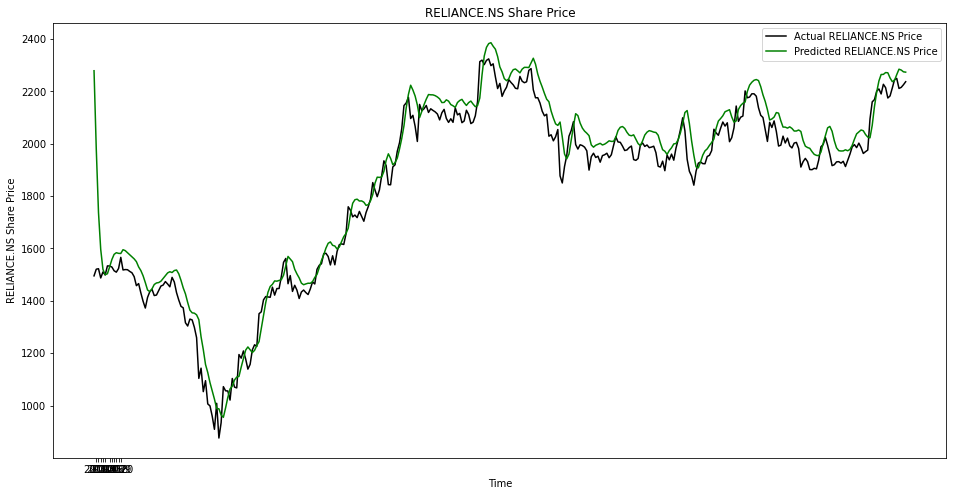

In [ ]:
xa=[1,2,3,4,5,7,8,9,10,11,12]
values_a = [2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021]

plt.figure(figsize=(16,8))
plt.plot(actual_prices, color='black', label=f"Actual {company} Price")
plt.plot(predicted_prices, color='green', label=f"Predicted {company} Price")
plt.title(f"{company} Share Price")
plt.xlabel('Time')
plt.xticks(xa,values_a)
plt.ylabel(f'{company} Share Price')
plt.legend()
plt.show()

In [ ]:
#Predict Next Day
real_data = [model_inputs[len(model_inputs) + 1 - prediction_days:len(model_inputs+1), 0]]
real_data = np.array(real_data)
real_data = np.reshape(real_data, (real_data.shape[0], real_data.shape[1],1))

prediction = model.predict(real_data)
prediction = scaler.inverse_transform(prediction)

print(f"Prediction: {prediction}")

Prediction: [[2279.2507]]
